<h1 style="color:#56B4E9;">Week 6 — Day 1</h1>

<h2 style="color:#0072B2;">Sprint 1 Planning and Neural Network Architecture</h2>

### ECG-Based Cardiac Diagnosis Using PTB-XL

This project uses clinical 12-lead ECG recordings to identify the following major diagnostic classes:

- `NORM`: Normal ECG
- `MI`: Myocardial Infarction
- `STTC`: ST/T Change
- `CD`: Conduction Disturbance
- `HYP`: Hypertrophy

<h2 style="color:#0072B2;">1. The Problem</h2>

A single ECG recording may contain more than one cardiac diagnosis. Therefore, the task cannot be treated as a regular multi-class classification problem where only one class is selected.

<span style="color:#D55E00;"><b>Problem:</b></span>  
The model must be able to predict multiple cardiac conditions for the same ECG recording.

<span style="color:#009E73;"><b>Decision:</b></span>  
The project will be treated as a multi-label classification problem.

Each ECG will be represented by five binary labels in the following order:

`[NORM, MI, STTC, CD, HYP]`

For example:

`[0, 1, 1, 0, 0]`

means that the ECG contains both myocardial infarction and ST/T changes.

<h2 style="color:#0072B2;">2. Why Start with a Baseline?</h2>

A baseline model provides a reference value that allows us to measure whether a more complex model produces a real improvement.

A neural network score has little meaning by itself. It must be compared with a simpler model trained and evaluated on the same task.

<span style="color:#009E73;"><b>Baseline Strategy:</b></span>  
A simple Logistic Regression model will be trained using statistical features extracted from the ECG leads.

Instead of using all 12,000 raw signal values directly, summary features such as mean, standard deviation, minimum, maximum, range, and RMS will be extracted from each lead.

This reduces the input from approximately 12,000 raw values to 72 statistical features.

<span style="color:#D55E00;"><b>Limitation:</b></span>  
Statistical features summarize the signal but do not preserve its temporal shape. Two ECG signals may have similar statistics while having different waveforms.

The neural network will later be evaluated to determine whether learning from the full temporal signal can outperform this baseline.

<h2 style="color:#0072B2;">3. Understanding the ECG Files</h2>

Each ECG recording is stored using two connected files:

- `.dat`: contains the numerical signal values.
- `.hea`: contains the information required to interpret the signal, such as the sampling frequency, lead names, and signal length.

The `wfdb` library reads both files together and returns the ECG as a NumPy array.

For the 100 Hz version of PTB-XL, each ECG has the following shape:

`(1000, 12)`

- `1000` rows represent the time samples collected over 10 seconds.
- `12` columns represent the 12 ECG leads.
- The time interval between two consecutive samples is 0.01 seconds.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

In [5]:
DATA_DIR = Path("../../cardiac-patient-monitoring/data/raw/ptb-xl")

metadata_path = DATA_DIR / "ptbxl_database.csv"
statements_path = DATA_DIR / "scp_statements.csv"
records_path = DATA_DIR / "records100"

print("Metadata file exists:", metadata_path.exists())
print("Statements file exists:", statements_path.exists())
print("Records folder exists:", records_path.exists())

Metadata file exists: True
Statements file exists: True
Records folder exists: True


In [6]:
metadata = pd.read_csv(metadata_path, index_col="ecg_id")

available_ecg_ids = []

for ecg_id, row in metadata.iterrows():
    record_path = DATA_DIR / row["filename_lr"]
    dat_file = record_path.with_suffix(".dat")
    hea_file = record_path.with_suffix(".hea")

    if dat_file.exists() and hea_file.exists():
        available_ecg_ids.append(ecg_id)

print("Total ECGs in metadata:", len(metadata))
print("Complete ECGs currently available:", len(available_ecg_ids))
print("First available ECG IDs:", available_ecg_ids[:10])

Total ECGs in metadata: 21799
Complete ECGs currently available: 2012
First available ECG IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


<h3 style="color:#009E73;">Available Data Decision</h3>

The metadata describes 21,799 ECG recordings, but only 2,012 complete recordings are currently available locally.

A recording is considered complete only when both its `.dat` and `.hea` files exist.

Therefore, the initial baseline will use the 2,012 successfully downloaded ECG recordings. The remaining metadata rows cannot be used until their corresponding signal files are downloaded.

<span style="color:#D55E00;"><b>Important:</b></span>  
This will be treated as a provisional baseline. The final baseline will be retrained after downloading the complete dataset.

In [8]:
available_metadata = metadata.loc[available_ecg_ids].copy()

print("Available metadata shape:", available_metadata.shape)
available_metadata.head()

Available metadata shape: (2012, 27)


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [9]:
sample_ecg_id = available_metadata.index[0]
sample_filename = available_metadata.loc[sample_ecg_id, "filename_lr"]
sample_path = DATA_DIR / sample_filename

signal, signal_info = wfdb.rdsamp(str(sample_path))

print("ECG ID:", sample_ecg_id)
print("Signal shape:", signal.shape)
print("Sampling frequency:", signal_info["fs"])
print("Lead names:", signal_info["sig_name"])

ECG ID: 1
Signal shape: (1000, 12)
Sampling frequency: 100
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


<h3 style="color:#009E73;">Reading the First ECG Signal</h3>

The first available ECG was loaded successfully with a shape of `(1000, 12)`.

This represents:

- 1,000 time samples collected over 10 seconds.
- 12 ECG leads.
- A sampling frequency of 100 Hz.

To make the x-axis medically meaningful, the sample indices will be converted into seconds.

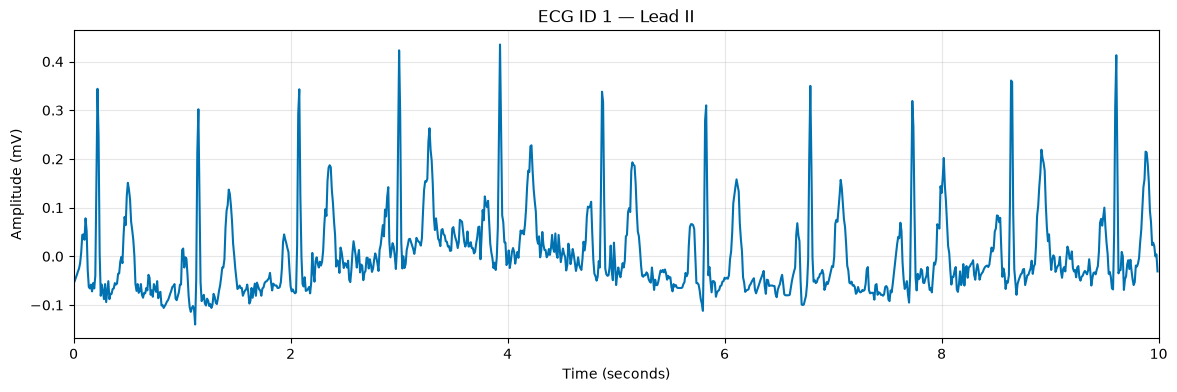

In [10]:
sampling_frequency = signal_info["fs"]
time = np.arange(signal.shape[0]) / sampling_frequency

lead_name = "II"
lead_index = signal_info["sig_name"].index(lead_name)

plt.figure(figsize=(14, 4))
plt.plot(time, signal[:, lead_index], color="#0072B2")

plt.title(f"ECG ID {sample_ecg_id} — Lead {lead_name}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.xlim(0, 10)
plt.grid(alpha=0.3)

plt.show()

<h3 style="color:#009E73;">Initial Signal Observation</h3>

The plotted Lead II signal contains repeated sharp peaks and visible changes over time.

Statistical features can preserve general information such as the amplitude range, average value, variability, and signal energy.

<span style="color:#D55E00;"><b>Limitation:</b></span>  
These statistics do not preserve the temporal order of the signal. They cannot fully represent the locations of the peaks, the intervals between beats, or the morphology of the ECG waves.

Therefore, statistical features are useful for building a simple and interpretable baseline, but they may not capture all medically important ECG patterns.

<h3 style="color:#009E73;">Why Use All 12 Leads?</h3>

Each ECG lead observes the electrical activity of the heart from a different direction.

A cardiac pattern may appear clearly in one lead but may be less visible or have a different shape in another lead.

Therefore, the baseline features will be extracted from all 12 leads rather than relying only on Lead II.

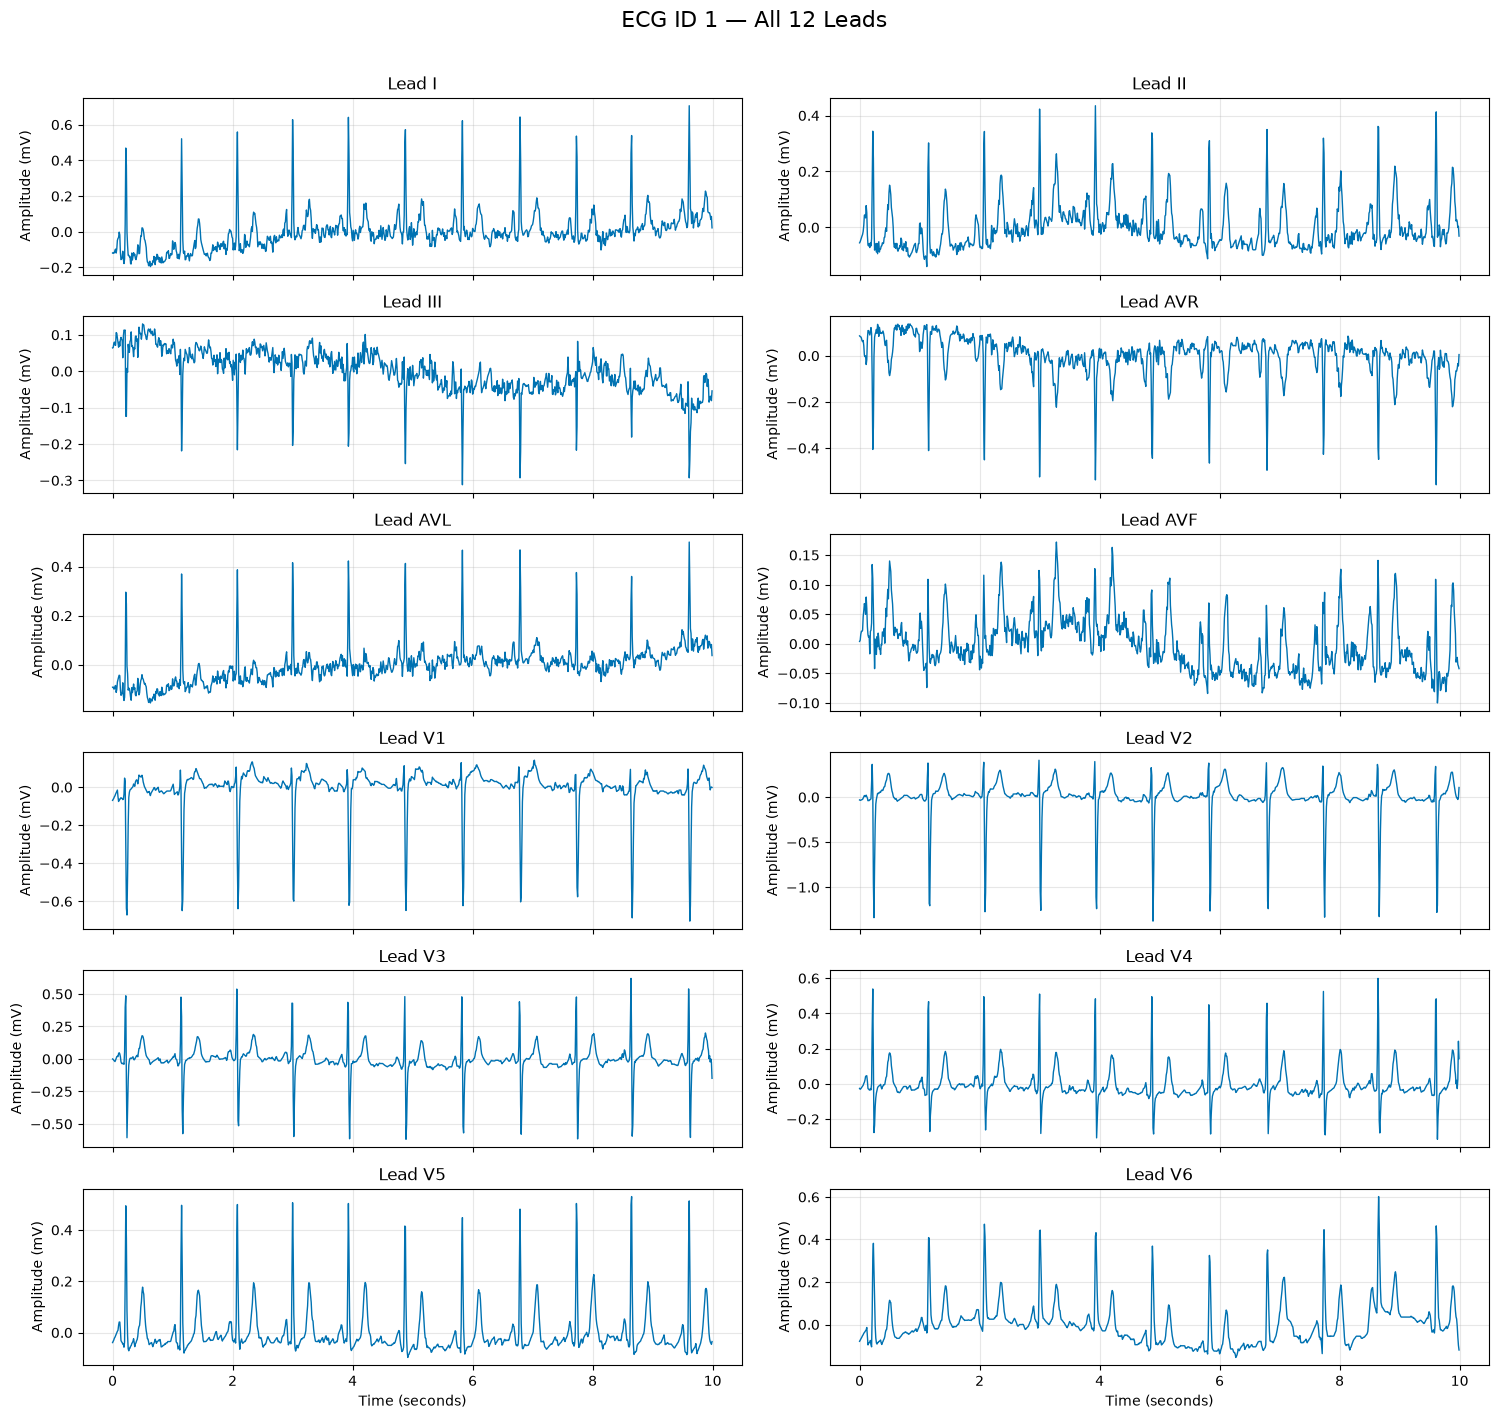

In [11]:
fig, axes = plt.subplots(6, 2, figsize=(15, 14), sharex=True)
axes = axes.flatten()

for lead_index, lead_name in enumerate(signal_info["sig_name"]):
    axes[lead_index].plot(
        time,
        signal[:, lead_index],
        color="#0072B2",
        linewidth=1
    )

    axes[lead_index].set_title(f"Lead {lead_name}")
    axes[lead_index].set_ylabel("Amplitude (mV)")
    axes[lead_index].grid(alpha=0.3)

for axis in axes[-2:]:
    axis.set_xlabel("Time (seconds)")

fig.suptitle(
    f"ECG ID {sample_ecg_id} — All 12 Leads",
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()

<h3 style="color:#009E73;">Comparison of the 12 Leads</h3>

The 12 leads show the same cardiac activity from different electrical directions.

The timing of the repeated cardiac cycles is related across the leads, but the amplitude, polarity, and waveform shape differ noticeably.

Some peaks appear positive in certain leads and negative in others. A pattern may also be clearer in one lead than in another.

<span style="color:#009E73;"><b>Decision:</b></span>  
Features will be extracted separately from all 12 leads so that the baseline does not depend on a single electrical view of the heart.

<h2 style="color:#0072B2;">4. Preparing the Diagnostic Labels</h2>

The `report` column contains free-text medical descriptions that are mainly written in German. The reports are not standardized and may express the same diagnosis using different words.

Using these reports directly would require a separate natural language processing pipeline.

<span style="color:#009E73;"><b>Decision:</b></span>  
The standardized `scp_codes` will be used with `scp_statements.csv` to create the diagnostic labels.

Only diagnostic statements will be mapped to the five main diagnostic classes:

`NORM`, `MI`, `STTC`, `CD`, and `HYP`.

In [12]:
scp_statements = pd.read_csv(statements_path, index_col=0)

print("SCP statements shape:", scp_statements.shape)
print("Columns:")
print(scp_statements.columns.tolist())

scp_statements.head(10)

SCP statements shape: (71, 12)
Columns:
['description', 'diagnostic', 'form', 'rhythm', 'diagnostic_class', 'diagnostic_subclass', 'Statement Category', 'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code', 'DICOM Code']


,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7
IMI,inferior myocardial infarction,1.0,NaN,NaN,MI,IMI,Myocardial Infarction,inferior myocardial infarction,161.0,NaN,NaN,NaN
ASMI,anteroseptal myocardial infarction,1.0,NaN,NaN,MI,AMI,Myocardial Infarction,anteroseptal myocardial infarction,165.0,NaN,NaN,NaN
LVH,left ventricular hypertrophy,1.0,NaN,NaN,HYP,LVH,Ventricular Hypertrophy,left ventricular hypertrophy,142.0,NaN,C71076,NaN
LAFB,left anterior fascicular block,1.0,NaN,NaN,CD,LAFB/LPFB,Intraventricular and intra-atrial Conduction d...,left anterior fascicular block,101.0,MDC_ECG_BEAT_BLK_ANT_L_HEMI,C62267,D3-33140
ISC_,non-specific ischemic,1.0,NaN,NaN,STTC,ISC_,Basic roots for coding ST-T changes and abnorm...,ischemic ST-T changes,226.0,NaN,NaN,NaN


In [13]:
import ast

available_metadata["scp_codes_dict"] = available_metadata["scp_codes"].apply(
    ast.literal_eval
)

available_metadata[
    ["scp_codes", "scp_codes_dict"]
].head()

,scp_codes,scp_codes_dict
ecg_id,,
1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}","{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}"
2,"{'NORM': 80.0, 'SBRAD': 0.0}","{'NORM': 80.0, 'SBRAD': 0.0}"
3,"{'NORM': 100.0, 'SR': 0.0}","{'NORM': 100.0, 'SR': 0.0}"
4,"{'NORM': 100.0, 'SR': 0.0}","{'NORM': 100.0, 'SR': 0.0}"
5,"{'NORM': 100.0, 'SR': 0.0}","{'NORM': 100.0, 'SR': 0.0}"


In [14]:
def get_diagnostic_classes(code_dictionary):
    classes = []

    for code in code_dictionary.keys():
        if code in scp_statements.index:
            is_diagnostic = scp_statements.loc[code, "diagnostic"]

            if is_diagnostic == 1:
                diagnostic_class = scp_statements.loc[
                    code, "diagnostic_class"
                ]

                if pd.notna(diagnostic_class):
                    classes.append(diagnostic_class)

    return sorted(set(classes))

In [15]:
available_metadata["diagnostic_classes"] = available_metadata[
    "scp_codes_dict"
].apply(get_diagnostic_classes)

available_metadata[
    ["scp_codes_dict", "diagnostic_classes"]
].head(10)

,scp_codes_dict,diagnostic_classes
ecg_id,,
1,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",[NORM]
2,"{'NORM': 80.0, 'SBRAD': 0.0}",[NORM]
3,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
4,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
5,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
6,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
7,"{'NORM': 100.0, 'SR': 0.0}",[NORM]
8,"{'IMI': 35.0, 'ABQRS': 0.0, 'SR': 0.0}",[MI]
9,"{'NORM': 100.0, 'SR': 0.0}",[NORM]


In [16]:
target_classes = ["NORM", "MI", "STTC", "CD", "HYP"]

for diagnostic_class in target_classes:
    available_metadata[diagnostic_class] = available_metadata[
        "diagnostic_classes"
    ].apply(
        lambda classes: int(diagnostic_class in classes)
    )

label_counts = available_metadata[target_classes].sum()

recordings_without_target = (
    available_metadata[target_classes].sum(axis=1) == 0
).sum()

print("Label counts:")
print(label_counts)

print(
    "\nRecordings without any of the five target classes:",
    recordings_without_target
)

available_metadata[
    ["diagnostic_classes"] + target_classes
].head(10)

Label counts:
NORM    1065
MI       373
STTC     474
CD       414
HYP      216
dtype: int64

Recordings without any of the five target classes: 22


,diagnostic_classes,NORM,MI,STTC,CD,HYP
ecg_id,,,,,,
1,[NORM],1,0,0,0,0
2,[NORM],1,0,0,0,0
3,[NORM],1,0,0,0,0
4,[NORM],1,0,0,0,0
5,[NORM],1,0,0,0,0
6,[NORM],1,0,0,0,0
7,[NORM],1,0,0,0,0
8,[MI],0,1,0,0,0
9,[NORM],1,0,0,0,0


<h3 style="color:#D55E00;">Recordings Without a Target Class</h3>

Twenty-two available ECG recordings do not belong to any of the five selected diagnostic classes.

These recordings may contain rhythm or waveform statements, but they do not provide a valid target for the current diagnostic task.

<span style="color:#009E73;"><b>Decision:</b></span>  
The 22 recordings will be excluded from the current model dataset because an `OTHER` class was not defined.

Normal ECG recordings will not be removed because they are explicitly represented by the `NORM` class.

In [17]:
model_data = available_metadata[
    available_metadata[target_classes].sum(axis=1) > 0
].copy()

print("Available complete ECGs:", len(available_metadata))
print("Removed without target:", len(available_metadata) - len(model_data))
print("ECGs used for modeling:", len(model_data))

Available complete ECGs: 2012
Removed without target: 22
ECGs used for modeling: 1990


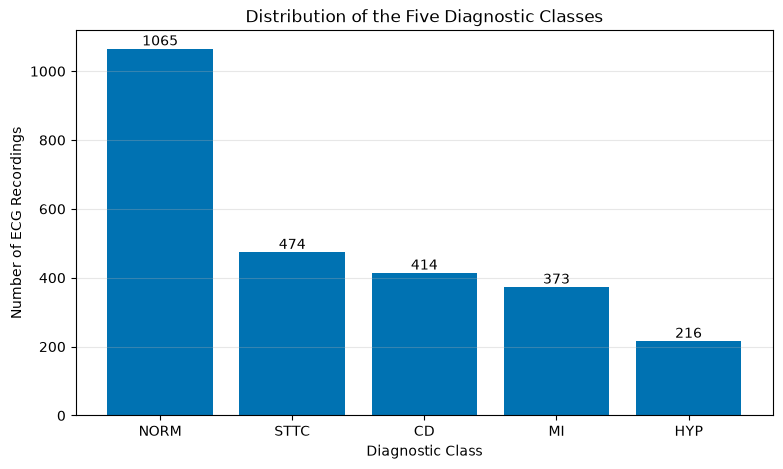

In [18]:
label_counts = model_data[target_classes].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    label_counts.index,
    label_counts.values,
    color="#0072B2"
)

plt.title("Distribution of the Five Diagnostic Classes")
plt.xlabel("Diagnostic Class")
plt.ylabel("Number of ECG Recordings")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        int(bar.get_height()),
        ha="center"
    )

plt.show()

<h3 style="color:#D55E00;">Class Imbalance and Evaluation Metrics</h3>

The diagnostic classes are not equally distributed. `NORM` is the largest class with 1,065 recordings, while `HYP` is the smallest with 216 recordings.

Accuracy alone may be misleading. For example, a model that always predicts `HYP = 0` would achieve approximately 89.1% accuracy for that label while detecting none of the actual HYP cases.

<span style="color:#009E73;"><b>Evaluation Decision:</b></span>

The main baseline metric will be Macro F1 because it gives equal importance to all five diagnostic classes.

Recall will receive special attention because a false negative means predicting that a disease is absent when it is actually present.

The following metrics will be reported:

- Precision for each class
- Recall for each class
- F1-score for each class
- Macro Precision
- Macro Recall
- Macro F1

In [19]:
feature_rows = []

for ecg_id, row in model_data.iterrows():
    record_path = DATA_DIR / row["filename_lr"]
    ecg_signal, ecg_info = wfdb.rdsamp(str(record_path))

    features = {"ecg_id": ecg_id}

    for lead_index, lead_name in enumerate(ecg_info["sig_name"]):
        lead_signal = ecg_signal[:, lead_index]

        features[f"{lead_name}_mean"] = np.mean(lead_signal)
        features[f"{lead_name}_std"] = np.std(lead_signal)
        features[f"{lead_name}_min"] = np.min(lead_signal)
        features[f"{lead_name}_max"] = np.max(lead_signal)
        features[f"{lead_name}_range"] = (
            np.max(lead_signal) - np.min(lead_signal)
        )
        features[f"{lead_name}_rms"] = np.sqrt(
            np.mean(lead_signal ** 2)
        )

    feature_rows.append(features)

features_df = pd.DataFrame(feature_rows).set_index("ecg_id")

print("Extracted feature shape:", features_df.shape)
features_df.head()

Extracted feature shape: (1990, 72)


,I_mean,I_std,I_min,I_max,I_range,I_rms,II_mean,II_std,II_min,II_max,...,V5_min,V5_max,V5_range,V5_rms,V6_mean,V6_std,V6_min,V6_max,V6_range,V6_rms
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,0.001508,0.109022,-0.195,0.706,0.901,0.109033,0.000723,0.083223,-0.140,0.435,...,-0.097,0.530,0.627,0.089206,0.000832,0.101939,-0.155,0.602,0.757,0.101943
2,-0.002181,0.133428,-0.349,0.664,1.013,0.133446,-0.000165,0.249745,-0.419,1.529,...,-0.492,1.839,2.331,0.228763,0.003389,0.186626,-0.204,1.394,1.598,0.186657
3,-0.002770,0.121200,-0.164,0.827,0.991,0.121231,0.005145,0.144389,-0.288,0.715,...,-0.175,0.851,1.026,0.110776,0.004239,0.100842,-0.128,0.705,0.833,0.100931
4,-0.003264,0.137803,-0.576,0.503,1.079,0.137841,0.003502,0.438161,-1.284,1.752,...,-1.269,2.221,3.490,0.394764,-0.004061,0.297912,-0.796,1.639,2.435,0.297940
5,-0.003769,0.082706,-0.267,0.440,0.707,0.082792,-0.003054,0.236781,-0.619,1.293,...,-0.187,1.493,1.680,0.210904,-0.000053,0.180209,-0.151,1.267,1.418,0.180209


In [20]:
X = features_df
y = model_data.loc[X.index, target_classes]

train_ids = model_data[
    model_data["strat_fold"].between(1, 8)
].index

validation_ids = model_data[
    model_data["strat_fold"] == 9
].index

test_ids = model_data[
    model_data["strat_fold"] == 10
].index

X_train = X.loc[X.index.intersection(train_ids)]
X_validation = X.loc[X.index.intersection(validation_ids)]
X_test = X.loc[X.index.intersection(test_ids)]

y_train = y.loc[X_train.index]
y_validation = y.loc[X_validation.index]
y_test = y.loc[X_test.index]

print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Test shape:", X_test.shape)

Training shape: (1505, 72)
Validation shape: (232, 72)
Test shape: (253, 72)


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        OneVsRestClassifier(
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42
            )
        )
    )
])

baseline_model.fit(X_train, y_train)

validation_predictions = baseline_model.predict(X_validation)

In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_validation,
        validation_predictions,
        target_names=target_classes,
        zero_division=0
    )
)

              precision    recall  f1-score   support

        NORM       0.68      0.81      0.74       111
          MI       0.48      0.76      0.59        55
        STTC       0.39      0.54      0.45        69
          CD       0.45      0.77      0.57        48
         HYP       0.49      0.73      0.59        30

   micro avg       0.51      0.73      0.60       313
   macro avg       0.50      0.72      0.59       313
weighted avg       0.52      0.73      0.61       313
 samples avg       0.56      0.73      0.61       313



<h3 style="color:#009E73;">Provisional Baseline Results</h3>

The Logistic Regression baseline was evaluated on the official PTB-XL validation fold.

### Main Results

- Macro Precision: `0.50`
- Macro Recall: `0.72`
- Macro F1-score: `0.59`

The model detected a useful proportion of the positive cardiac cases, but its lower precision indicates that it also produced false-positive diagnoses.

`NORM` achieved the highest F1-score of `0.74`, while `STTC` achieved the lowest F1-score of `0.45`.

<span style="color:#009E73;"><b>Baseline to Beat:</b></span>  
Future neural network models should achieve a Macro F1-score higher than `0.59` on the same validation split.

<span style="color:#D55E00;"><b>Important:</b></span>  
This is a provisional baseline trained on the currently available subset of PTB-XL. The final baseline must be retrained after downloading the complete dataset.

<h2 style="color:#0072B2;">5. Understanding a Neural Network</h2>

A neuron first calculates a weighted sum of its inputs:

$$
z = x_1w_1 + x_2w_2 + \cdots + x_nw_n + b
$$

The weights determine the strength and direction of the relationship between each input and the neuron.

The bias shifts the neuron's activation boundary. Two neurons may receive the same inputs and use the same weights but behave differently because they have different bias values.

The result is then passed through an activation function:

$$
a = f(z)
$$

For a hidden neuron using ReLU:

$$
a = \max(0,z)
$$

A negative weighted result is blocked, while a positive result continues to the next layer.

<h3 style="color:#009E73;">From Logistic Regression to a Neural Network</h3>

The Logistic Regression baseline is similar to an output layer containing five independent neurons without hidden layers.

Each classifier directly connects the input features to one diagnostic probability.

A neural network adds hidden layers between the input and output. Each hidden neuron learns a different weighted combination of the inputs, and later layers combine these learned patterns.

Without non-linear activation functions, multiple linear layers would collapse into a single linear transformation. ReLU introduces non-linearity and allows different neurons to become active for different input patterns.

<h3 style="color:#009E73;">Planned Network Architecture</h3>

The initial neural network will follow this general structure:

`ECG Input → Hidden Layer → ReLU → Hidden Layer → ReLU → Output Layer → Sigmoid`

The output layer will contain five neurons:

- Neuron 1: probability of `NORM`
- Neuron 2: probability of `MI`
- Neuron 3: probability of `STTC`
- Neuron 4: probability of `CD`
- Neuron 5: probability of `HYP`

Sigmoid will be applied independently to each output because one ECG may contain multiple diagnostic classes.

<h2 style="color:#0072B2;">6. Sprint 1 Plan</h2>

<h3 style="color:#009E73;">Sprint Goal</h3>

Build and evaluate the first neural network for multi-label cardiac diagnosis using PTB-XL ECG signals, then compare its performance with a classical Logistic Regression baseline.

The provisional baseline achieved a validation Macro F1-score of `0.59`.

<h3 style="color:#009E73;">Sprint Backlog</h3>

### Day 1 — Dataset and Baseline

- Finalize the PTB-XL dataset structure.
- Inspect the metadata and raw ECG signals.
- Convert SCP-ECG codes into five diagnostic labels.
- Build a statistical-feature Logistic Regression baseline.
- Understand neurons, weights, biases, layers, and network architecture.

### Day 2 — Activations, Forward Propagation, and Loss

- Compare ReLU, sigmoid, and tanh.
- Perform a small forward-pass calculation.
- Select the correct output activation.
- Understand binary cross-entropy for multi-label classification.

### Day 3 — Backpropagation and Optimization

- Understand the training loop.
- Explain gradients and backpropagation.
- Compare different learning rates.
- Compare Adam and SGD.

### Day 4 — Keras Neural Network

- Build the first neural network.
- Train using the official PTB-XL splits.
- Plot training and validation curves.
- Add dropout and batch normalization.

### Day 5 — Tuning and Evaluation

- Tune one hyperparameter at a time.
- Apply EarlyStopping and ModelCheckpoint.
- Compare the neural network with the baseline.
- Complete the Sprint Review and Retrospective.

<h3 style="color:#D55E00;">Current Blocker</h3>

Only 2,012 complete ECG recordings are currently available locally.

The current results are provisional. The final experiments must be repeated after downloading the complete `records100` dataset.

<h3 style="color:#009E73;">Acceptance Criteria</h3>

- The notebook runs from beginning to end without errors.
- The same patient-safe PTB-XL folds are used for all models.
- Macro F1, Precision, and Recall are reported.
- The neural network is compared fairly with the baseline.
- The test fold remains untouched until final evaluation.
- Every result and conclusion is based on actual notebook output.

<h2 style="color:#0072B2;">7. Day 1 Conclusion</h2>

During Day 1, the PTB-XL dataset was prepared for the ECG-based cardiac diagnosis project.

The available ECG files were matched with their metadata by verifying that both the `.dat` and `.hea` files existed. From 21,799 metadata records, 2,012 complete ECG recordings were available locally. After removing 22 recordings that did not belong to any of the five selected diagnostic classes, 1,990 recordings remained for the provisional experiment.

The standardized SCP-ECG codes were mapped into five multi-label targets:

- `NORM`
- `MI`
- `STTC`
- `CD`
- `HYP`

A statistical-feature baseline was created by extracting 72 features from the 12 ECG leads. Logistic Regression with a One-vs-Rest strategy achieved:

- Macro Precision: `0.50`
- Macro Recall: `0.72`
- Macro F1-score: `0.59`

This Macro F1-score will serve as the provisional reference for evaluating the neural network.

The analysis also showed why statistical features are limited: they summarize the amplitude and variability of the ECG but do not preserve its temporal morphology or the intervals between cardiac events.

Finally, the relationship between Logistic Regression and neural networks was established. A neuron calculates a weighted sum, adds a bias, and applies an activation function. Hidden layers allow the network to learn multiple intermediate representations, while non-linear activations prevent the network from collapsing into a single linear transformation.

<span style="color:#009E73;"><b>Final Day 1 Decision:</b></span>  
The next stage will investigate activation functions, forward propagation, and the correct loss function for the multi-label cardiac diagnosis task.

<span style="color:#D55E00;"><b>Limitation:</b></span>  
The current results are provisional because only part of the PTB-XL waveform dataset is available locally. All final experiments must be repeated using the complete dataset.